# GloBUS — China residential buildings: from socioeconomic development to cement demand

A teaching walk-through of the GloBUS pipeline for **one region — China (region 20) — and its residential buildings**, kept end-to-end so the whole logic chain is easy to follow:

> socio-economic development (population / urbanisation / floor-area per capita) → floor-area **stock** → dynamic stock model (DSM) → **concrete** → **cement**

**Scope of this notebook**
- **One region:** China (region 20).
- **Full residential split kept:** both **areas** (Urban + Rural) × **4 building types** (Detached, Semi-detached, Apartments, High-rise) = **8 streams**, summed to the region's residential total. *(Commercial buildings are out of scope.)*
- **Ends at cement:** GloBUS natively reports *concrete*; we convert concrete → cement with a single content factor (≈ 0.13 kg cement per kg concrete). Glass and building-sand are dropped because the target output is cement.

All code below is extracted from the full multi-region GloBUS model, reduced to this single region and the residential streams.

> ⚠️ Pre-1971 values are model **spin-up**, not real data. Before 1971 only population is observed (Maddison series); the area share and floor-area per capita are back-cast (Step 2).

> **Single-stream version (20260621):** Steps 1–3 build the full region picture — population (Step 1), floor area (Step 2) and the urban/rural × type split (Step 3); from Step 4 on we follow **only one stream — urban detached** (the highest-intensity residential type) through stock → DSM → concrete → cement.

<img src="asset/pic/flow_chart.png" alt="GloBUS Flow Chart" width="900"/>

## 0 · Configuration & imports

Region is fixed to China; the cement-content factor matches the project's cement pipeline. Everything else is derived automatically.

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
import sys
workspace_path = os.path.abspath("..")
sys.path.insert(0, os.path.join(workspace_path, "notebook", "asset", "script"))
from dynamic_stock_model import DynamicStockModel as DSM

In [7]:
# Self-contained: run from the GloBUS/ folder (inputs in data/, ODYM engine alongside).
DATA = Path('../data').resolve()

# ===== scope =====
REGION = 20                                         # 20 = China (IMAGE 3.0 region)
AREAS  = ['Urban', 'Rural']                         # keep the full urban/rural split
TYPES  = ['Detached', 'Semi-detached', 'Appartments', 'High-rise']   # 4 residential types

# =================

# full GloBUS model horizon, including the pre-1971 spin-up tail
YEARS  = np.arange(1721, 2061)
years_ramp                = np.arange(1721, 1820)   # 1721-1819: linear ramp from ~0 (DSM spin-up)
years_backcast            = np.arange(1820, 1970)   # 1820-1969: reconstructed past (1970 onward = known IMAGE data)
years_backcast_floor_area = np.arange(1820, 1971)   # 1820-1970: floor area has no 1970 value (its IMAGE starts at 1971)

# the 4 types are spelled differently across the input files; map each spelling
population_share_columns = ['Detached', 'Semi-detached', 'Appartment', 'High-rise']   # population_share_by_building_type.csv columns
floor_area_per_capita_columns = ['1', '2', '3', '4']                                       # floorspace_per_capita_by_building_type.csv columns (same order)
region_column = str(REGION)

print(f'Region {REGION} (China) | areas {AREAS} | {len(AREAS)*len(TYPES)} residential streams')

Region 20 (China) | areas ['Urban', 'Rural'] | 8 residential streams


## 1 · Population: data → spin-up tail

This section is **all about population**, end to end: first read the region-level series, then build the pre-1971 **spin-up tail** that the dynamic stock model needs.

- **population** (millions) — IMAGE scenario data, 1970–2060;
- **urban / rural share** — derived from the urban & rural population series (rural = rural ⁄ total, urban = 1 − rural).

The two helpers defined here — `ramp` and `make_tail` — do the tail-stitching and are **reused unchanged** by the floor-area section (Step 2), so they are not redefined there.

In [8]:
# population (millions): load the ready-made annual series (already cleaned & interpolated, 1970-2060)
population_1970_2060 = pd.read_csv(DATA/'total_population.csv', index_col=0)[region_column]
urban_population_1970_2060 = pd.read_csv(DATA/'urban_population.csv', index_col=0)[region_column]
rural_population_1970_2060 = pd.read_csv(DATA/'rural_population.csv', index_col=0)[region_column]
rural_share_1970_2060 = rural_population_1970_2060 / population_1970_2060
urban_share_1970_2060  = 1 - rural_share_1970_2060

In [9]:
print(f'2020 — population {population_1970_2060.loc[2020]:.0f} M | urban share {urban_share_1970_2060.loc[2020]:.3f}')

2020 — population 1420 M | urban share 0.550


### Spin-up tail (1721–1969): warming up the DSM

The dynamic stock model needs ~1–2 building lifetimes of construction history before 1971; otherwise the standing stock has no age structure and the first modelled year shows a false demolition spike. So each population driver is extended backwards:

- **1820–1969** — population from the **Maddison** historical series (the only real data); the rural/urban share is **back-cast from this region's own 1970→1980 trend**, capped at the global-max rural share.
- **1721–1819** — a linear **ramp to ~0**, so the 1721 stock ≈ 0 (no cold-start spike).

`ramp` and `make_tail` (next cell) assemble the full 1721–2060 series; both are reused by Step 2.

In [10]:
# ---------- 1721-1819: linear ramp to zero ----------
ramp = lambda v: pd.Series(np.maximum(0.0, v - v/100 * (1820 - years_ramp)), index=years_ramp)

# ---------- stitch ramp + back-cast + IMAGE into the full 1721-2060 series ----------
def make_tail(historical_segment, image_segment):
    return pd.concat([ramp(historical_segment.loc[1820]), historical_segment, image_segment]).reindex(YEARS)

In [11]:
# ---------- 1820-1969 back-cast (1970 onward is known IMAGE data) ----------
# population: Maddison fraction-of-1970 × the actual 1970 population (Maddison ends at 1969 here)
maddison_population_index = pd.read_csv(DATA/'historical_population_index_maddison.csv', index_col=0)[region_column]
population_1820_1969 = maddison_population_index.loc[1820:1969] * population_1970_2060.loc[1970]

# rural share: back-cast from the 1970->1980 trend, capped at the global-max rural share
global_total_population_1970_2060 = pd.read_csv(DATA/'total_population.csv', index_col=0)
global_rural_population_1970_2060 = pd.read_csv(DATA/'rural_population.csv', index_col=0)
gloabl_rural_share_1970_2060 = global_rural_population_1970_2060 / global_total_population_1970_2060
max_rural_share  = gloabl_rural_share_1970_2060.to_numpy().max()

rural_share_trend = (1 - rural_share_1970_2060.loc[1980] / rural_share_1970_2060.loc[1970]) / 10 * 100      # %/yr increase
rural_share_1820_1969 = pd.Series(np.minimum(max_rural_share, rural_share_1970_2060.loc[1970] * ((100 + rural_share_trend)/100) ** (1970 - years_backcast)), index=years_backcast)
urban_share_1820_1969 = 1 - rural_share_1820_1969

In [12]:
# stitch ramp + back-cast + IMAGE into the full 1721-2060 population & urban/rural share series
population_1721_2060  = make_tail(population_1820_1969, population_1970_2060)
urban_share_1721_2060 = make_tail(urban_share_1820_1969, urban_share_1970_2060)
rural_share_1721_2060 = make_tail(rural_share_1820_1969, rural_share_1970_2060)

**Visualize wave 1 — the 1820–1969 back-cast.** China's population is reconstructed back to 1820 (Maddison fraction-of-1970 × the actual 1970 value) and stitched directly onto the IMAGE data from 1970. *(Urban/rural shares and floor-area per capita get the same back-cast; population is shown as the clearest example.)*

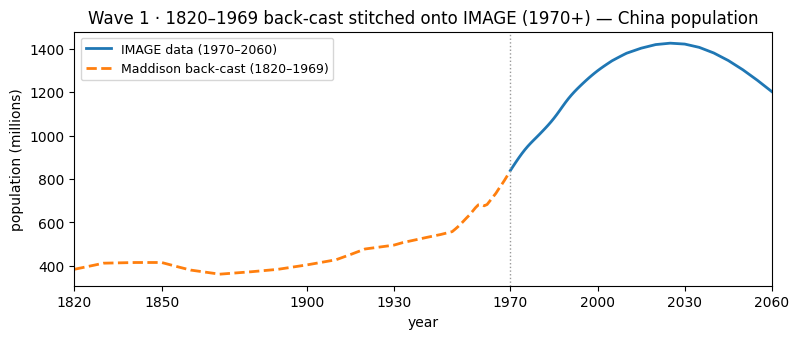

In [13]:
fig = plt.figure(figsize=(9, 3.3))
ax1 = plt.subplot(111)
population_1970_2060.plot(lw=2, label='IMAGE data (1970–2060)', ax=ax1)
population_1820_1969.plot(lw=2, ls='--', label='Maddison back-cast (1820–1969)', ax=ax1)
ax1.axvline(1970, color='0.6', ls=':', lw=1)
ax1.set_xlabel('year')
ax1.set_ylabel('population (millions)')
ax1.set_xlim(1820, 2060)
ax1.set_xticks([1820, 1850, 1900, 1930, 1970, 2000, 2030, 2060])
ax1.legend(fontsize=9)
ax1.set_title('Wave 1 · 1820–1969 back-cast stitched onto IMAGE (1970+) — China population')
plt.show()

**Visualize wave 2 — the 1721–1819 linear ramp to zero.** The back-cast is then extended down to (almost) zero in 1721, so the dynamic stock model starts from an empty stock and warms up over ~250 years. The full assembled 1721–2060 series, colour-coded by segment:

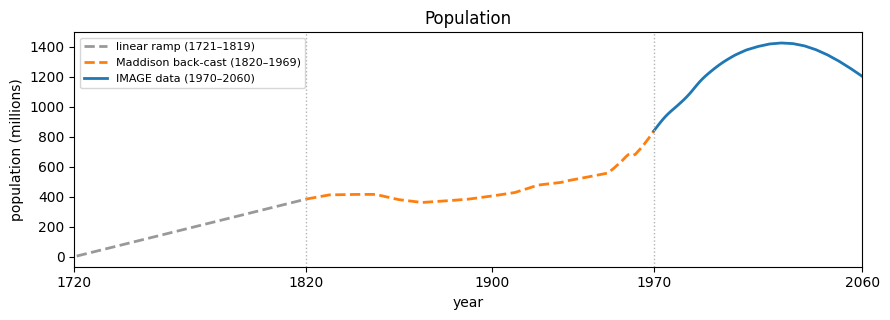

In [14]:
# Wave 2: the full 1721–2060 series after adding the linear ramp (population)
fig, ax = plt.subplots(figsize=(9, 3.3))
ramp_seg  = population_1721_2060.loc[1721:1820]    # +1yr overlap so segments connect visually
hist_seg  = population_1721_2060.loc[1820:1970]
image_seg = population_1721_2060.loc[1970:2060]
ax.plot(ramp_seg.index,  ramp_seg.values,  color='0.6', lw=2, ls='--', label='linear ramp (1721–1819)')
ax.plot(hist_seg.index,  hist_seg.values,  color='C1', lw=2, ls='--', label='Maddison back-cast (1820–1969)')
ax.plot(image_seg.index, image_seg.values, color='C0', lw=2, label='IMAGE data (1970–2060)')
for yr in (1820, 1970):
    ax.axvline(yr, color='0.7', ls=':', lw=1)

ax.set_xlim(1720, 2060)
ax.set_xticks([1720, 1820, 1900, 1970, 2060])
ax.set_xlabel('year')
ax.set_ylabel('population (millions)')
ax.set_title('Population')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
# population checkpoint on the assembled 1721–2060 series
print(f'population (M)  1850={population_1721_2060.loc[1850]:.0f}  1971={population_1721_2060.loc[1971]:.0f}  2060={population_1721_2060.loc[2060]:.0f}')

population (M)  1850=415  1971=860  2060=1202


## 2 · Floor area (per capita): data → spin-up tail

Same treatment for the second driver, **floor area per capita** (m²/cap, urban & rural): read the IMAGE data, then build its spin-up tail — **reusing `ramp` / `make_tail` from Step 1** (no helper redefined here).

Unlike population, floor area has **no historical dataset**, so its pre-1971 part is a **trend back-cast**: the annual decline is a single **global** mean over all 26 regions (1971–1980), floored at the global minimum. Its IMAGE series also starts only in 1971 (no 1970 value), so this reconstruction runs **1820–1970** (`years_backcast_floor_area`).

In [16]:
# floor-area per capita (m²/cap), urban & rural — load the ready-made pivoted tables (year × region, 1971-2060)
floorarea_per_cap_urban_1971_2060 = pd.read_csv(DATA/'residential_floorarea_per_capita_urban.csv', index_col=0)[region_column]
floorarea_per_cap_rural_1971_2060 = pd.read_csv(DATA/'residential_floorarea_per_capita_rural.csv', index_col=0)[region_column]

In [17]:
print(f'2020 — floor area urban {floorarea_per_cap_urban_1971_2060.loc[2020]:.1f} / rural {floorarea_per_cap_rural_1971_2060.loc[2020]:.1f} m²/cap')

2020 — floor area urban 41.3 / rural 54.2 m²/cap


In [18]:
# floor-area per cap: back-cast by the GLOBAL mean annual decline, floored at the global min.
# NB: floor-area IMAGE data starts only in 1971 (no 1970), so this reconstruction runs 1820-1970.
def floor_area_backcast(urban_or_rural, floorarea_1971_2060):
    floorarea_all = pd.read_csv(DATA/ f'residential_floorarea_per_capita_{urban_or_rural}.csv', index_col=0)
    ratio    = floorarea_all.loc[1971:1980].to_numpy() / floorarea_all.loc[1972:1981].to_numpy()
    floor_area_trend = (1 - ratio.mean()) * 100                                            # %/yr decline (global)
    results = pd.Series(np.maximum(floorarea_all.to_numpy().min(),
                     floorarea_1971_2060.loc[1971] * ((100 - floor_area_trend)/100) ** (1971 - years_backcast_floor_area)), index=years_backcast_floor_area)
    return results

In [19]:
floorarea_per_cap_urban_1820_1970 = floor_area_backcast('urban', floorarea_per_cap_urban_1971_2060)
floorarea_per_cap_rural_1820_1970 = floor_area_backcast('rural', floorarea_per_cap_rural_1971_2060)

In [20]:
# stitch ramp + back-cast + IMAGE into the full 1721-2060 floor-area-per-capita series
floorarea_per_cap_urban_1721_2060 = make_tail(floorarea_per_cap_urban_1820_1970, floorarea_per_cap_urban_1971_2060)
floorarea_per_cap_rural_1721_2060 = make_tail(floorarea_per_cap_rural_1820_1970, floorarea_per_cap_rural_1971_2060)

**Visualize the floor-area-per-capita tail.** Urban & rural, with line style marking each segment.

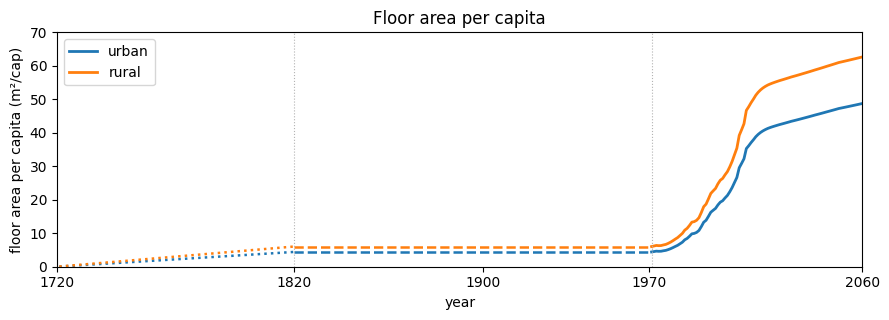

In [21]:
# floor-area-per-capita tail (urban & rural): dotted=ramp, dashed=trend back-cast, solid=IMAGE
fig = plt.figure(figsize=(9, 3.3))

ax1 = plt.subplot(111)
for series, color, name in [(floorarea_per_cap_urban_1721_2060, 'C0', 'urban'), (floorarea_per_cap_rural_1721_2060, 'C1', 'rural')]:
    ax1.plot(series.loc[1721:1820].index, series.loc[1721:1820].values, color=color, lw=1.8, ls=':')   # ramp
    ax1.plot(series.loc[1820:1971].index, series.loc[1820:1971].values, color=color, lw=1.8, ls='--')  # back-cast
    ax1.plot(series.loc[1971:2060].index, series.loc[1971:2060].values, color=color, lw=2,   label=name)  # IMAGE

for yr in (1820, 1971):
    ax1.axvline(yr, color='0.7', ls=':', lw=.8)

ax1.set_xlim(1720, 2060)
ax1.set_xticks([1720, 1820, 1900, 1970, 2060])
ax1.set_ylim(0, 70)
ax1.set_xlabel('year')
ax1.set_ylabel('floor area per capita (m²/cap)')
ax1.set_title('Floor area per capita')
ax1.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 3 · The urban × type split (4 constant shares)

Within an area, the region's floor area is divided among the 4 building types by a **time-invariant share** that combines *how many people live in each type* (population share) with *how much space each type uses per person* (m²/cap):

$$\text{type share}_{a,t} \;=\; \frac{(\text{population share}_{a,t}) \times (\text{m}^2/\text{cap}_{a,t})}{\sum_{t'} (\text{population share}_{a,t'}) \times (\text{m}^2/\text{cap}_{a,t'})}$$

The full model splits **both** areas (2 × 4 = 8 shares). Since this version follows only the **urban · Detached** stream, we compute just the **urban** split here — the 4 urban shares sum to 1. *(The rural block is omitted as unused.)*

In [22]:
population_shares = pd.read_csv(DATA/'population_share_by_building_type.csv')
floorarea_per_capita = pd.read_csv(DATA/'floorarea_per_capita_by_building_type.csv')

In [23]:
# Urban — floor-area share per building type (normalised population share × m²/cap; the 4 sum to 1)
urban_population_share = population_shares.loc[(population_shares.Region == REGION) & (population_shares.Area == 'Urban'),
                                              population_share_columns].iloc[0].astype(float).to_numpy()
urban_floor_area_per_capita = floorarea_per_capita.loc[(floorarea_per_capita.Region == REGION) & (floorarea_per_capita.Area == 'Urban'),
                                                        floor_area_per_capita_columns].iloc[0].astype(float).to_numpy()
weights_urban = (urban_population_share / urban_population_share.sum()) * urban_floor_area_per_capita
weights_urban = weights_urban / weights_urban.sum()

# the four constant urban floor-area shares (sum to 1)
urban_detached_share      = weights_urban[0]
urban_semi_detached_share = weights_urban[1]
urban_appartments_share   = weights_urban[2]
urban_high_rise_share     = weights_urban[3]

In [24]:
print('urban floor-area shares by type (sum to 1):')
print(pd.Series({'Detached': urban_detached_share, 'Semi-detached': urban_semi_detached_share, 'Appartments': urban_appartments_share, 'High-rise': urban_high_rise_share}).round(3))

urban floor-area shares by type (sum to 1):
Detached         0.251
Semi-detached    0.291
Appartments      0.254
High-rise        0.205
dtype: float64


## 4 · Floor-area stock → dynamic stock model (urban · Detached)

We now follow a **single stream — urban detached** — through the rest of the pipeline. Stock = population × urban share × floor-area per cap × the urban·Detached type share (from Step 3). The dynamic stock model then gives the annual **build** (inflow) and **demolish** (outflow).

In [25]:
area, building_type = 'Urban', 'Detached'   # the single stream this version models
n_years = len(YEARS)

In [26]:
# floor-area stock (Mm²) for the urban-detached stream
floorarea_stock = population_1721_2060 * urban_share_1721_2060 * floorarea_per_cap_urban_1721_2060 * urban_detached_share

In [27]:
lifetimes = pd.read_csv(DATA/'building_lifetimes.csv')

In [28]:
lifetimes[(lifetimes['Region'] == REGION) & (lifetimes['Area'] == 'Urban')]

,Region,Building_type,Area,Shape,Scale
152,20,Detached,Urban,2.0,33.851375
153,20,Semi-detached,Urban,2.0,39.493271
154,20,Appartments,Urban,2.0,53.598010
155,20,High-rise,Urban,2.0,56.418958


In [29]:
lifetime_row = lifetimes[(lifetimes['Region'] == REGION) & (lifetimes['Area'] == 'Urban') & (lifetimes['Building_type'] == 'Detached')]

In [30]:
param_shape = lifetime_row['Shape'].values[0]
param_scale = lifetime_row['Scale'].values[0]

In [31]:
dsm = DSM(t=np.arange(n_years), s=floorarea_stock.values,
          lt={'Type': 'Weibull',
              'Shape': np.full(n_years, param_shape),
              'Scale': np.full(n_years, param_scale)})

In [32]:
stock_cohort, outflow_cohort, inflow = dsm.compute_stock_driven_model(NegativeInflowCorrect=True)

In [33]:
outflow_cohort[outflow_cohort < 0] = 0   # clip numerical-noise negative outflow

In [34]:
floorarea_inflow  = pd.Series(inflow, index=YEARS)                                   # build    (Mm²/yr)
floorarea_outflow = pd.Series(outflow_cohort.sum(axis=1), index=YEARS).clip(lower=0)  # demolish (Mm²/yr)
print(f'2020 urban-detached build = {floorarea_inflow.loc[2020]:.0f} Mm²/yr')

2020 urban-detached build = 351 Mm²/yr


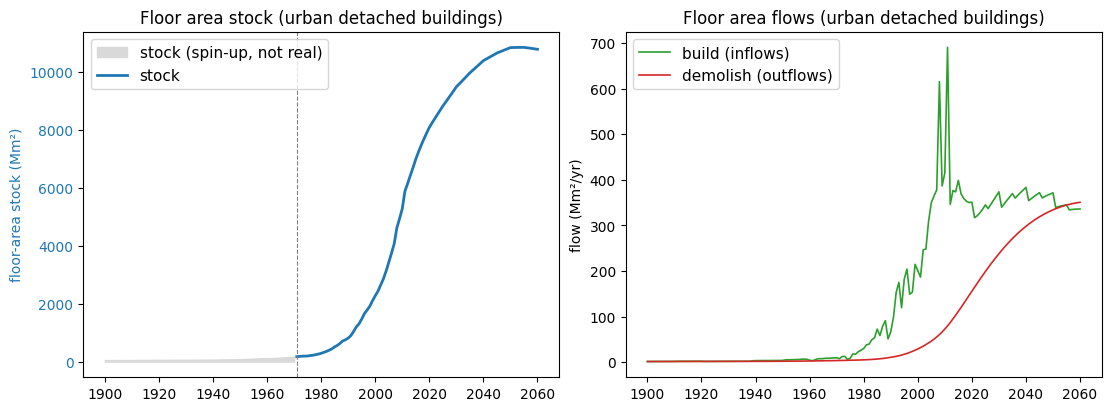

In [35]:
fig = plt.figure(figsize=(11, 4), constrained_layout=True)

ax1 = plt.subplot(121)
ax1.fill_between(np.arange(1900, 1971), floorarea_stock.loc[1900:1970], color='0.85', label='stock (spin-up, not real)')
ax1.plot(floorarea_stock.loc[1971:2060].index, floorarea_stock.loc[1971:2060], color='C0', lw=2, label='stock')
ax1.set_ylabel('floor-area stock (Mm²)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.axvline(1971, color='0.5', ls='--', lw=.8)
h1, l1 = ax1.get_legend_handles_labels()
ax1.legend(h1, l1, fontsize=11, loc='upper left')
ax1.set_title('Floor area stock (urban detached buildings)')

ax2 = plt.subplot(122)
ax2.plot(floorarea_inflow.loc[1900:2060].index,  floorarea_inflow.loc[1900:2060],  color='C2', lw=1.2, label='build (inflows)')
ax2.plot(floorarea_outflow.loc[1900:2060].index, floorarea_outflow.loc[1900:2060], color='C3', lw=1.2, label='demolish (outflows)')
ax2.set_ylabel('flow (Mm²/yr)')
ax2.set_title('Floor area flows (urban detached buildings)')
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h2,l2, fontsize=11, loc='upper left')

plt.show()

## 5 · Floor area → Concrete

Concrete flow = floor-area flow × the **Detached** concrete intensity (kg/m²).

In [36]:
building_materials = pd.read_csv(DATA/'material_intensity_by_building_type.csv')

In [37]:
building_materials

,Region,Building_type,concrete,glass
0,1,Detached,876.71,2.68
1,1,Semi-detached,1208.13,1.07
2,1,Appartments,995.92,6.35
3,1,High-rise,1040.35,1.20
4,2,Detached,472.10,3.32
...,...,...,...,...
99,25,High-rise,910.21,4.42
100,26,Detached,846.33,2.68
101,26,Semi-detached,1208.13,1.07
102,26,Appartments,995.92,6.35


In [38]:
building_materials[(building_materials.Region == REGION) & (building_materials.Building_type == 'Detached')]

,Region,Building_type,concrete,glass
76,20,Detached,2613.94,7.82


In [39]:
concrete_intensity_detached = building_materials[(building_materials.Region == REGION) & (building_materials.Building_type == 'Detached')]['concrete'].values[0]

In [40]:
concrete_inflow  = floorarea_inflow  * concrete_intensity_detached # Mkg/yr
concrete_outflow = floorarea_outflow * concrete_intensity_detached

In [41]:
print(f'Detached concrete intensity = {concrete_intensity_detached:.0f} kg/m²')
print(f'2020 urban-detached concrete demand = {concrete_inflow.loc[2020]:,.0f} Mkg')

Detached concrete intensity = 2614 kg/m²
2020 urban-detached concrete demand = 918,151 Mkg


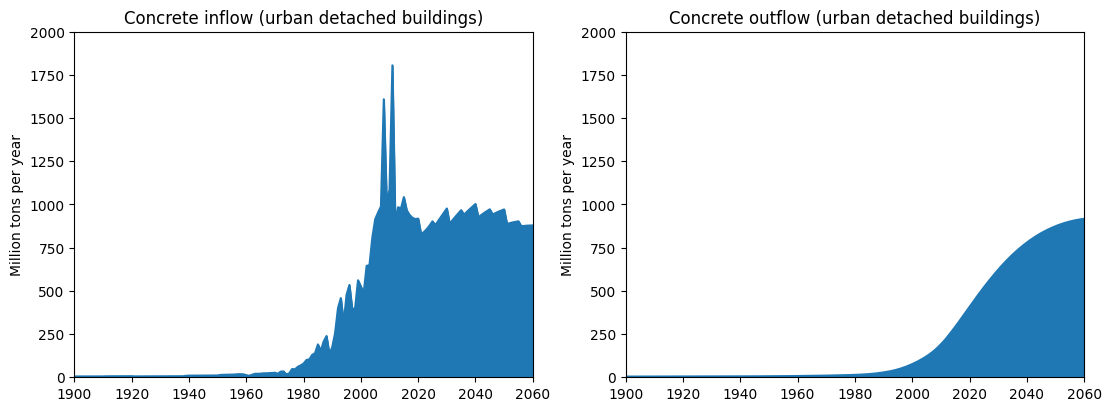

In [42]:
fig = plt.figure(figsize=(11, 4), constrained_layout=True)

ax1 = plt.subplot(121)
(concrete_inflow/1e3).plot.area(ax=ax1)
ax1.set_title('Concrete inflow (urban detached buildings)')
ax1.set(xlim=(1900, 2060), ylim=(0, 2e3), ylabel='Million tons per year')

ax2 = plt.subplot(122)
(concrete_outflow/1e3).plot.area(ax=ax2)
ax2.set_title('Concrete outflow (urban detached buildings)')
ax2.set(xlim=(1900, 2060), ylim=(0, 2e3), ylabel='Million tons per year')

plt.show()

## 6 · Concrete → Cement

**Cement = concrete × cement-content factor** (≈ 0.13 kg cement / kg concrete; set 1.0 for the raw concrete proxy).

In [43]:
cement_content_factor = 0.13     # kg cement / kg concrete

In [44]:
cement_inflow  = concrete_inflow  * cement_content_factor   # Mkg/yr
cement_outflow = concrete_outflow * cement_content_factor

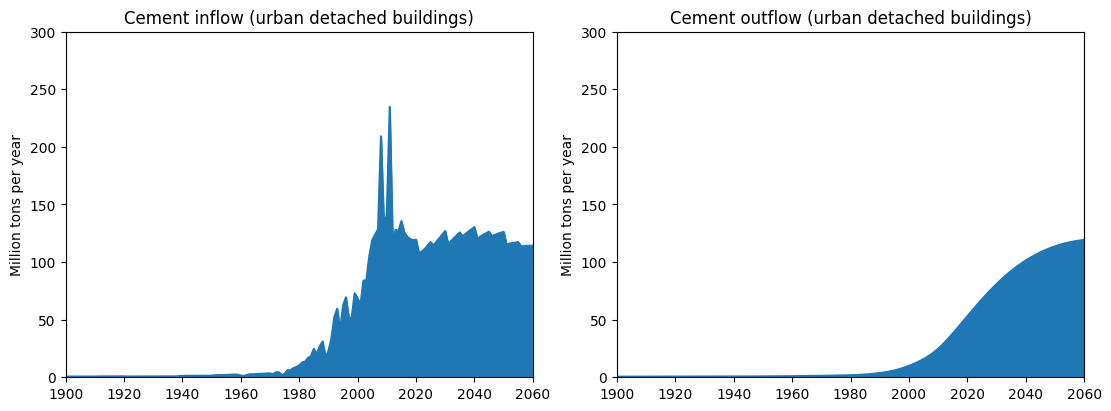

In [45]:
fig = plt.figure(figsize=(11, 4), constrained_layout=True)

ax1 = plt.subplot(121)
(cement_inflow/1e3).plot.area(ax=ax1)
ax1.set_title('Cement inflow (urban detached buildings)')
ax1.set(xlim=(1900, 2060), ylim=(0, 3e2), ylabel='Million tons per year')

ax2 = plt.subplot(122)
(cement_outflow/1e3).plot.area(ax=ax2)
ax2.set_title('Cement outflow (urban detached buildings)')
ax2.set(xlim=(1900, 2060), ylim=(0, 3e2), ylabel='Million tons per year')

plt.show()

## 8 · Material efficiency (ME) levers

We layer four demand-side ME strategies onto the urban-detached stream:

- **ME1 — more intensive use:** less **floor area per capita** (→ `intensive_rate = 0.93`, 7% lower).
- **ME2 — lifetime extension:** longer **Weibull `Scale`** (→ `70/30 ≈ 2.33×`, ~30 → ~70 yr).
- **ME3 — lightweight design:** less **cement per m²** of new build (→ `mi_factor_he = 0.9`, 10% lower material intensity).
- **ME4 — EoL recycling & reuse:** recycled cement from demolition offsets primary demand (`inflow − outflow × rate`, rate → `0.15`).

ME1–ME2 reshape the *floor-area* flows; ME3–ME4 act on the *cement* conversion. All four are **phased in linearly from 2020 to 2060** (BAU = no change before 2020). Each lever is shown alone vs BAU, then all four combined.

In [46]:
# ME policy settings (default parameter values)
ME_START, ME_END = 2020, 2060            # all levers ramp in linearly over this window
intensive_rate = 0.93                    # ME1: floor area per capita ends 7% lower
lifetime_extension_rate = 70 / 30        # ME2: Weibull Scale ends ~2.33x longer (~30 -> ~70 yr)
mi_factor_he = 0.90                      # ME3: cement per m2 ends 10% lower
eol_recycle_reuse_rate = 0.15            # ME4: 15% of demolition cement recycled/reused by 2060

# linear phase-in weight: 0 up to ME_START, rising to 1 at ME_END
phase_in = np.clip((YEARS - ME_START) / (ME_END - ME_START), 0.0, 1.0)
# baseline cement intensity (cement kg per m2 of floor area)
cement_per_m2 = concrete_intensity_detached * cement_content_factor
print(f'phase-in:  2020={phase_in[YEARS==2020][0]:.2f}  2040={phase_in[YEARS==2040][0]:.2f}  2060={phase_in[YEARS==2060][0]:.2f}'
      f'   |   baseline cement intensity = {cement_per_m2:.0f} kg/m2')

phase-in:  2020=0.00  2040=0.50  2060=1.00   |   baseline cement intensity = 340 kg/m2


In [47]:
# floor-area pipeline: per-capita floor area + per-year Weibull Scale -> stock, build, outflow, gross cement
def urban_detached_cement(floorarea_per_cap, scale_per_year):
    stock = population_1721_2060 * urban_share_1721_2060 * floorarea_per_cap * urban_detached_share
    dsm = DSM(t=np.arange(n_years), s=stock.values,
              lt={'Type': 'Weibull',
                  'Shape': np.full(n_years, param_shape),
                  'Scale': np.asarray(scale_per_year, dtype=float)})
    _, outflow_cohort, inflow = dsm.compute_stock_driven_model(NegativeInflowCorrect=True)
    outflow_cohort[outflow_cohort < 0] = 0
    build   = pd.Series(inflow, index=YEARS)                                    # new build (Mm2/yr)
    outflow = pd.Series(outflow_cohort.sum(axis=1), index=YEARS).clip(lower=0)  # demolish (Mm2/yr)
    cement  = build * cement_per_m2                                             # gross primary cement, base intensity (Mkg/yr)
    return stock, build, outflow, cement

In [48]:
# BAU reference run (constant Scale, unchanged floor area per capita)
scale_bau = np.full(n_years, param_scale)
stock_bau, build_bau, outflow_bau, cement_bau = urban_detached_cement(floorarea_per_cap_urban_1721_2060, scale_bau)
cement_outflow_bau = outflow_bau * cement_per_m2                  # demolition cement available for recycling (Mkg/yr)
print(f'BAU check - 2020 cement {cement_bau.loc[2020]:,.0f} Mkg (Step 6 gave {cement_inflow.loc[2020]:,.0f})')

BAU check - 2020 cement 119,360 Mkg (Step 6 gave 119,360)


### 8.1 · ME1 — more intensive use

Multiply floor area per capita by a factor that stays 1.0 until 2020 and falls linearly to `intensive_rate` (0.93) by 2060. Less floor area per person → smaller stock → less new build → less cement.

In [49]:
# ME1 lever: floor area per capita scaled by 1.0 -> intensive_rate across 2020-2060
intensive_factor = 1 + (intensive_rate - 1) * phase_in
floorarea_per_cap_urban_me1 = floorarea_per_cap_urban_1721_2060 * intensive_factor
print(f'urban floor area per cap 2060 - BAU {floorarea_per_cap_urban_1721_2060.loc[2060]:.1f} '
      f'-> ME1 {floorarea_per_cap_urban_me1.loc[2060]:.1f} m2/cap')

urban floor area per cap 2060 - BAU 48.8 -> ME1 45.3 m2/cap


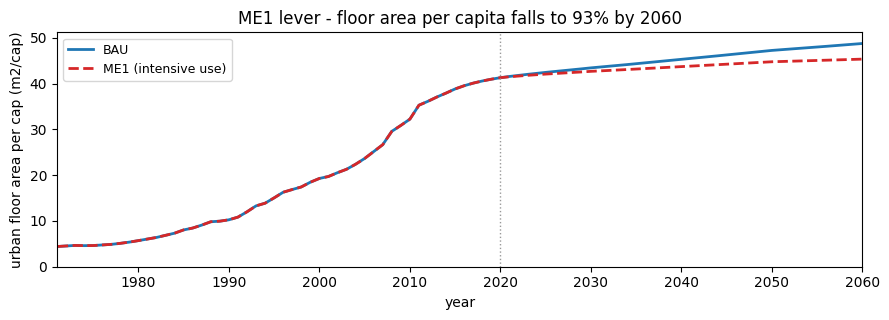

In [50]:
# visualize the ME1 lever on floor area per capita
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(YEARS, floorarea_per_cap_urban_1721_2060, color='C0', lw=2, label='BAU')
ax.plot(YEARS, floorarea_per_cap_urban_me1, color='C3', lw=2, ls='--', label='ME1 (intensive use)')
ax.axvline(ME_START, color='0.6', ls=':', lw=1)
ax.set_xlim(1971, 2060); ax.set_ylim(0, None)
ax.set_xlabel('year'); ax.set_ylabel('urban floor area per cap (m2/cap)')
ax.set_title('ME1 lever - floor area per capita falls to 93% by 2060')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [51]:
# run the pipeline with the ME1 floor area (Scale unchanged)
stock_me1, build_me1, outflow_me1, cement_me1 = urban_detached_cement(floorarea_per_cap_urban_me1, scale_bau)
print(f'2060 cement - BAU {cement_bau.loc[2060]:,.0f} -> ME1 {cement_me1.loc[2060]:,.0f} Mkg')

2060 cement - BAU 114,254 -> ME1 102,347 Mkg


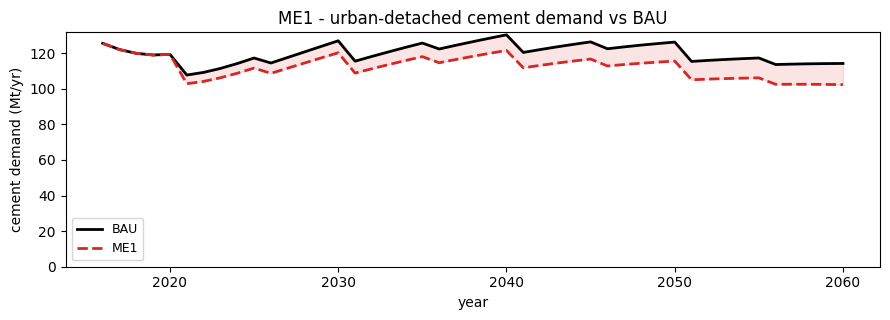

In [52]:
# cement demand: BAU vs ME1 (Mt/yr = Mkg/1e3)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(cement_bau.loc[yrs].index, cement_bau.loc[yrs]/1e3, color='k',  lw=2, label='BAU')
ax.plot(cement_me1.loc[yrs].index, cement_me1.loc[yrs]/1e3, color='C3', lw=2, ls='--', label='ME1')
ax.fill_between(cement_bau.loc[yrs].index, cement_me1.loc[yrs]/1e3, cement_bau.loc[yrs]/1e3, color='C3', alpha=0.12)
ax.set_xlabel('year'); ax.set_ylabel('cement demand (Mt/yr)'); ax.set_ylim(0, None)
ax.set_title('ME1 - urban-detached cement demand vs BAU')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 8.2 · ME2 — lifetime extension

Keep buildings standing longer by ramping the Weibull `Scale` from its baseline up to `lifetime_extension_rate × baseline` (≈2.33×) across 2020-2060. Longer-lived stock → slower demolition → less replacement build → less cement. The `Scale` now varies by cohort year, which `compute_stock_driven_model` already supports.

In [53]:
# ME2 lever: Weibull Scale ramped from baseline to lifetime_extension_rate x baseline over 2020-2060
scale_me2 = param_scale * (1 + (lifetime_extension_rate - 1) * phase_in)
# mean Weibull lifetime = Scale * gamma(1 + 1/Shape); Shape=2 -> gamma(1.5) = 0.886
mean_factor = 0.886
print(f'Weibull Scale - BAU {param_scale:.1f} (~{param_scale*mean_factor:.0f} yr mean) '
      f'-> ME2 2060 {scale_me2[-1]:.1f} (~{scale_me2[-1]*mean_factor:.0f} yr)')

Weibull Scale - BAU 33.9 (~30 yr mean) -> ME2 2060 79.0 (~70 yr)


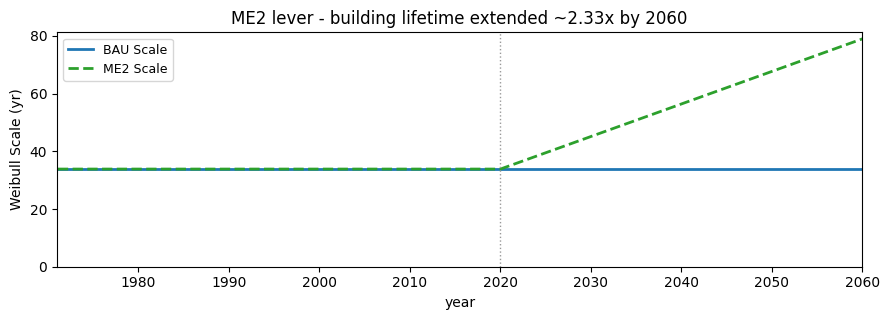

In [54]:
# visualize the ME2 lever on the Weibull Scale (characteristic lifetime)
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(YEARS, np.full(n_years, param_scale), color='C0', lw=2, label='BAU Scale')
ax.plot(YEARS, scale_me2, color='C2', lw=2, ls='--', label='ME2 Scale')
ax.axvline(ME_START, color='0.6', ls=':', lw=1)
ax.set_xlim(1971, 2060); ax.set_ylim(0, None)
ax.set_xlabel('year'); ax.set_ylabel('Weibull Scale (yr)')
ax.set_title('ME2 lever - building lifetime extended ~2.33x by 2060')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [55]:
# run the pipeline with the extended lifetime (floor area unchanged)
stock_me2, build_me2, outflow_me2, cement_me2 = urban_detached_cement(floorarea_per_cap_urban_1721_2060, scale_me2)
print(f'2060 cement - BAU {cement_bau.loc[2060]:,.0f} -> ME2 {cement_me2.loc[2060]:,.0f} Mkg')

2060 cement - BAU 114,254 -> ME2 74,389 Mkg


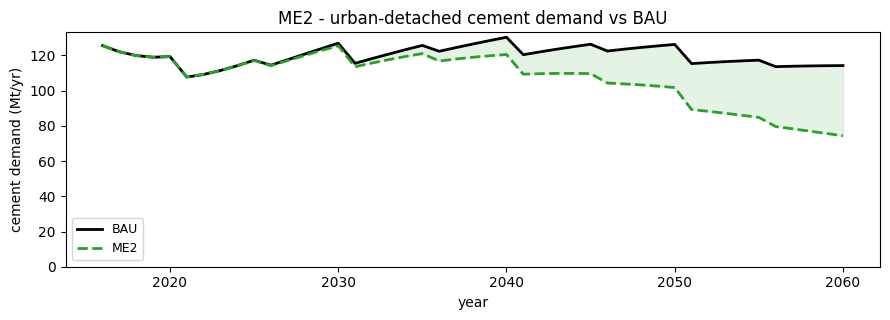

In [56]:
# cement demand: BAU vs ME2 (Mt/yr)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(cement_bau.loc[yrs].index, cement_bau.loc[yrs]/1e3, color='k',  lw=2, label='BAU')
ax.plot(cement_me2.loc[yrs].index, cement_me2.loc[yrs]/1e3, color='C2', lw=2, ls='--', label='ME2')
ax.fill_between(cement_bau.loc[yrs].index, cement_me2.loc[yrs]/1e3, cement_bau.loc[yrs]/1e3, color='C2', alpha=0.12)
ax.set_xlabel('year'); ax.set_ylabel('cement demand (Mt/yr)'); ax.set_ylim(0, None)
ax.set_title('ME2 - urban-detached cement demand vs BAU')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 8.3 · ME3 — lightweight design

Reduce the **cement intensity** (cement per m² of new build) by a factor ramping 1.0 → `mi_factor_he` (0.9) over 2020-2060 — same buildings, ~10% less cement each. This scales the *new-build* cement directly; demolished stock keeps its as-built (base) intensity.

In [57]:
# ME3 lever: cement intensity of new build scaled 1.0 -> mi_factor_he across 2020-2060
mi_factor = 1 + (mi_factor_he - 1) * phase_in
print(f'cement intensity 2060 - BAU {cement_per_m2:.0f} -> ME3 {cement_per_m2*mi_factor[-1]:.0f} kg/m2')

cement intensity 2060 - BAU 340 -> ME3 306 kg/m2


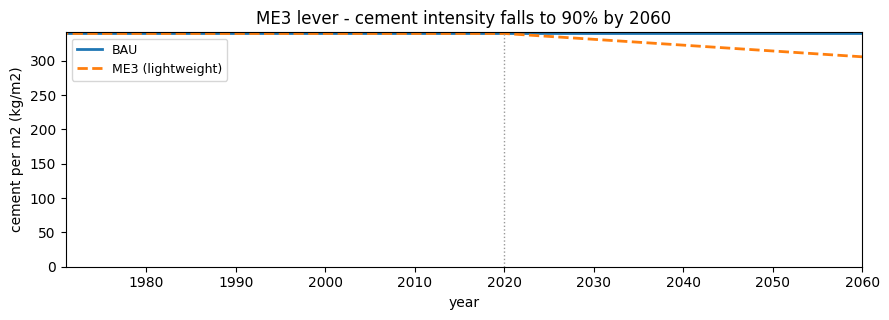

In [58]:
# visualize the ME3 lever on cement intensity (cement per m2)
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(YEARS, np.full(n_years, cement_per_m2), color='C0', lw=2, label='BAU')
ax.plot(YEARS, cement_per_m2 * mi_factor, color='C1', lw=2, ls='--', label='ME3 (lightweight)')
ax.axvline(ME_START, color='0.6', ls=':', lw=1)
ax.set_xlim(1971, 2060); ax.set_ylim(0, None)
ax.set_xlabel('year'); ax.set_ylabel('cement per m2 (kg/m2)')
ax.set_title('ME3 lever - cement intensity falls to 90% by 2060')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [59]:
# new-build cement with lighter design (BAU floor-area flows, reduced intensity)
cement_me3 = cement_bau * mi_factor
print(f'2060 cement - BAU {cement_bau.loc[2060]:,.0f} -> ME3 {cement_me3.loc[2060]:,.0f} Mkg')

2060 cement - BAU 114,254 -> ME3 102,828 Mkg


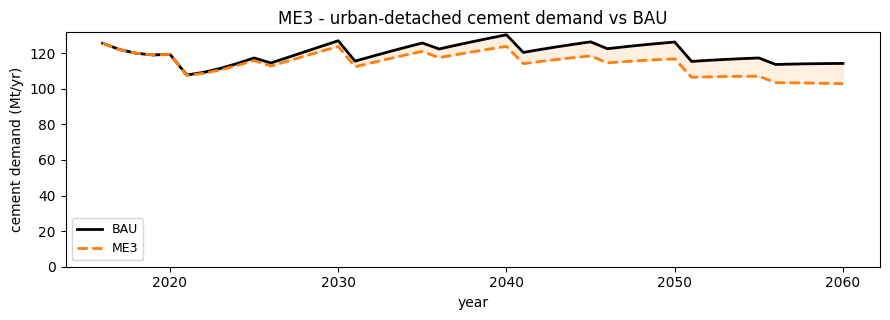

In [60]:
# cement demand: BAU vs ME3 (Mt/yr)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(cement_bau.loc[yrs].index, cement_bau.loc[yrs]/1e3, color='k',  lw=2, label='BAU')
ax.plot(cement_me3.loc[yrs].index, cement_me3.loc[yrs]/1e3, color='C1', lw=2, ls='--', label='ME3')
ax.fill_between(cement_bau.loc[yrs].index, cement_me3.loc[yrs]/1e3, cement_bau.loc[yrs]/1e3, color='C1', alpha=0.12)
ax.set_xlabel('year'); ax.set_ylabel('cement demand (Mt/yr)'); ax.set_ylim(0, None)
ax.set_title('ME3 - urban-detached cement demand vs BAU')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 8.4 · ME4 — End-of-life recycling & reuse

Recover cement from demolished buildings to offset primary demand: **net primary cement = inflow − outflow × recycle-rate**, with the rate ramping 0 → `eol_recycle_reuse_rate` (0.15) over 2020-2060. The more demolition there is, the larger the secondary supply.

In [61]:
# ME4 lever: recycle/reuse rate ramps 0 -> eol_recycle_reuse_rate across 2020-2060
recycle_rate = eol_recycle_reuse_rate * phase_in
recycled_cement = cement_outflow_bau * recycle_rate          # secondary cement supply (Mkg/yr)
print(f'2060 - demolition cement {cement_outflow_bau.loc[2060]:,.0f} Mkg, '
      f'recycled {recycled_cement.loc[2060]:,.0f} Mkg ({eol_recycle_reuse_rate:.0%})')

2060 - demolition cement 119,206 Mkg, recycled 17,881 Mkg (15%)


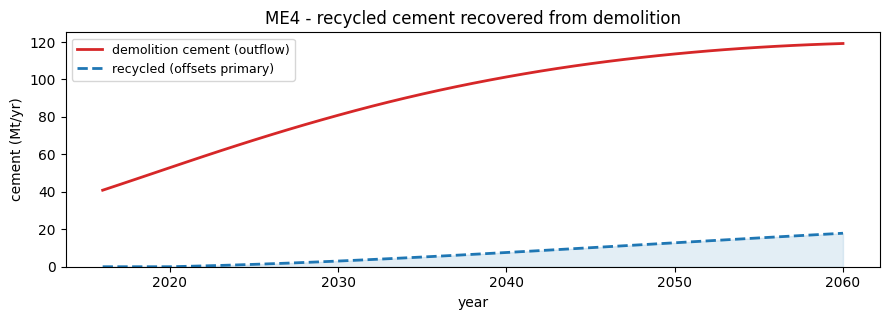

In [62]:
# visualize the ME4 secondary supply: recycled share of demolition cement
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(cement_outflow_bau.loc[yrs].index, cement_outflow_bau.loc[yrs]/1e3, color='C3', lw=2, label='demolition cement (outflow)')
ax.plot(recycled_cement.loc[yrs].index, recycled_cement.loc[yrs]/1e3, color='C0', lw=2, ls='--', label='recycled (offsets primary)')
ax.fill_between(recycled_cement.loc[yrs].index, 0, recycled_cement.loc[yrs]/1e3, color='C0', alpha=0.12)
ax.set_xlabel('year'); ax.set_ylabel('cement (Mt/yr)'); ax.set_ylim(0, None)
ax.set_title('ME4 - recycled cement recovered from demolition')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [63]:
# primary cement after EoL recycling (BAU floor-area & intensity, minus recycled supply)
cement_me4 = cement_bau - recycled_cement
print(f'2060 cement - BAU {cement_bau.loc[2060]:,.0f} -> ME4 {cement_me4.loc[2060]:,.0f} Mkg')

2060 cement - BAU 114,254 -> ME4 96,373 Mkg


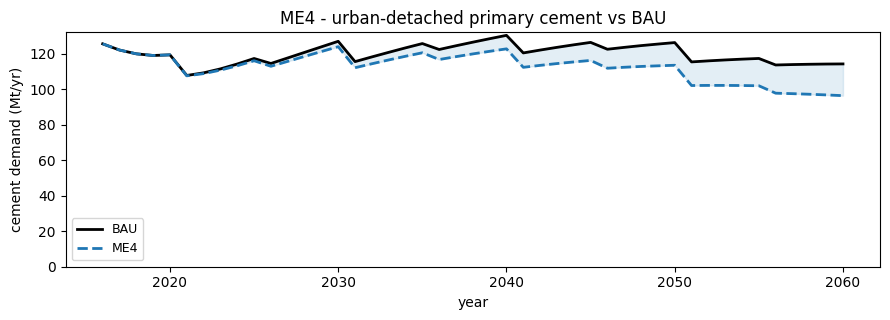

In [64]:
# cement demand: BAU vs ME4 (Mt/yr)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.plot(cement_bau.loc[yrs].index, cement_bau.loc[yrs]/1e3, color='k',  lw=2, label='BAU')
ax.plot(cement_me4.loc[yrs].index, cement_me4.loc[yrs]/1e3, color='C0', lw=2, ls='--', label='ME4')
ax.fill_between(cement_bau.loc[yrs].index, cement_me4.loc[yrs]/1e3, cement_bau.loc[yrs]/1e3, color='C0', alpha=0.12)
ax.set_xlabel('year'); ax.set_ylabel('cement demand (Mt/yr)'); ax.set_ylim(0, None)
ax.set_title('ME4 - urban-detached primary cement vs BAU')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 8.5 · All four levers & comparison

Combine everything — reduced floor area (ME1) + extended lifetime (ME2) reshape the floor-area flows, then lighter design (ME3) + EoL recycling (ME4) act on the cement of that scenario. Compare every lever alone and all four together, including the **cumulative** cement over 2020-2060.

In [65]:
# ME1+ME2 reshape the floor-area flows; ME3+ME4 then act on that scenario's cement
stock_all, build_all, outflow_all, _ = urban_detached_cement(floorarea_per_cap_urban_me1, scale_me2)
cement_all = build_all * cement_per_m2 * mi_factor - (outflow_all * cement_per_m2) * recycle_rate
scenarios = {'BAU': cement_bau, 'ME1 intensive use': cement_me1, 'ME2 lifetime ext.': cement_me2,
             'ME3 lightweight': cement_me3, 'ME4 EoL recycling': cement_me4, 'ALL (ME1-4)': cement_all}
colors = {'BAU': 'k', 'ME1 intensive use': 'C3', 'ME2 lifetime ext.': 'C2',
          'ME3 lightweight': 'C1', 'ME4 EoL recycling': 'C0', 'ALL (ME1-4)': 'C4'}

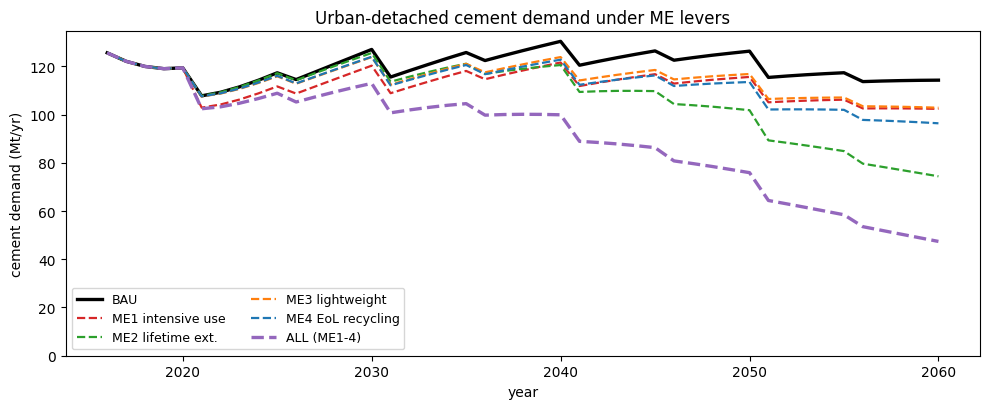

In [66]:
# cement demand: all scenarios 2016-2060 (Mt/yr)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(10, 4.2))
for name, series in scenarios.items():
    ax.plot(series.loc[yrs].index, series.loc[yrs]/1e3,
            lw=2.4 if name in ('BAU', 'ALL (ME1-4)') else 1.6,
            color=colors[name], ls='-' if name == 'BAU' else '--', label=name)
ax.set_xlabel('year'); ax.set_ylabel('cement demand (Mt/yr)'); ax.set_ylim(0, None)
ax.set_title('Urban-detached cement demand under ME levers')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

In [67]:
# cumulative cement 2020-2060 (Mkg -> Mt: /1000) and saving vs BAU
cumulative_mt = {name: series.loc[2020:2060].sum() / 1000 for name, series in scenarios.items()}
for name, total in cumulative_mt.items():
    saving = (1 - total / cumulative_mt['BAU']) * 100
    print(f'{name:20s} cumulative 2020-2060 = {total:8,.0f} Mt cement   ({saving:5.1f}% vs BAU)')

BAU                  cumulative 2020-2060 =    4,911 Mt cement   (  0.0% vs BAU)
ME1 intensive use    cumulative 2020-2060 =    4,568 Mt cement   (  7.0% vs BAU)
ME2 lifetime ext.    cumulative 2020-2060 =    4,345 Mt cement   ( 11.5% vs BAU)
ME3 lightweight      cumulative 2020-2060 =    4,665 Mt cement   (  5.0% vs BAU)
ME4 EoL recycling    cumulative 2020-2060 =    4,581 Mt cement   (  6.7% vs BAU)
ALL (ME1-4)          cumulative 2020-2060 =    3,595 Mt cement   ( 26.8% vs BAU)


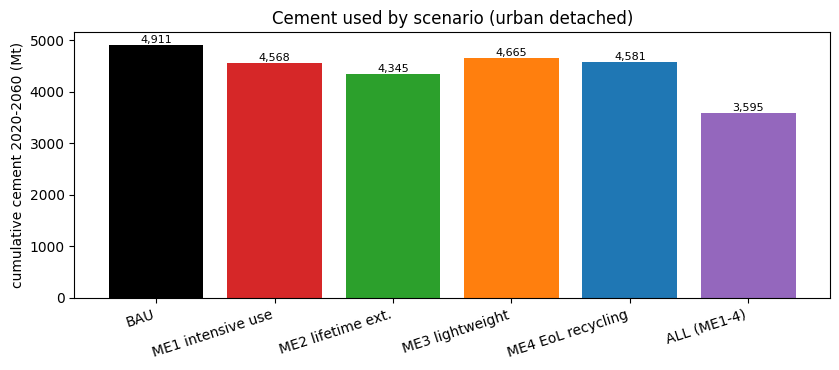

In [68]:
# bar chart of cumulative cement 2020-2060
fig, ax = plt.subplots(figsize=(8.5, 3.8))
names = list(cumulative_mt)
ax.bar(names, [cumulative_mt[n] for n in names], color=[colors[n] for n in names])
ax.set_ylabel('cumulative cement 2020-2060 (Mt)')
ax.set_title('Cement used by scenario (urban detached)')
for i, n in enumerate(names):
    ax.text(i, cumulative_mt[n], f'{cumulative_mt[n]:,.0f}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=18, ha='right')
plt.tight_layout(); plt.show()